In [10]:
import tensorflow as tf

In [11]:
tf.__version__

'2.17.0'

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Dropout, GlobalMaxPooling2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import cifar10

In [13]:
#carregando o dataset e normalizando os dados

(X_treinamento, y_treinamento), (X_teste, y_teste) = cifar10.load_data()
X_treinamento, X_teste = X_treinamento / 255, X_teste / 255
y_treinamento, y_teste = y_treinamento.flatten(), y_teste.flatten()
print(X_treinamento.shape)
print(y_treinamento.shape)

(50000, 32, 32, 3)
(50000,)


In [14]:
#número de classes

K = len(np.unique(y_treinamento))
K

10

In [15]:
#criando a rede neural através da API funcional

i = Input(shape=X_treinamento[0].shape)
x = Conv2D(32, (3,3), activation='relu', padding='same')(i)
x = BatchNormalization()(x)
x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)
x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)
x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2,2))(x)

x = Flatten()(x)

x = Dropout(0.2)(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(K, activation='softmax')(x)

model = Model(i,x)

In [16]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [17]:
#utilizando data augmentation

batch_size = 32
data_generator = tf.keras.preprocessing.image.ImageDataGenerator(width_shift_range=0.1,
                                                                 height_shift_range=0.1,
                                                                 horizontal_flip=True)
train_generator = data_generator.flow(X_treinamento, y_treinamento, batch_size)
steps_per_epoch = X_treinamento.shape[0] // batch_size
r = model.fit(train_generator, validation_data=(X_teste, y_teste), steps_per_epoch=steps_per_epoch, epochs=10)

Epoch 1/10


/home/lucasarenhardt/.local/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1724096108.365713   17238 service.cc:146] XLA service 0x7ab69401e6b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1724096108.365741   17238 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2024-08-19 16:35:08.419600: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-08-19 16:35:08.718278: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 890

  19/1562 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.1605 - loss: 5.5275 

I0000 00:00:1724096112.835009   17238 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1561/1562 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4120 - loss: 1.8133

...

1562/1562 ━━━━━━━━━━━━━━━━━━━━ 1s 352us/step - accuracy: 0.6250 - loss: 1.0829 - val_accuracy: 0.4844 - val_loss: 1.7593
Epoch 3/10
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.6303 - loss: 1.0594 - val_accuracy: 0.7147 - val_loss: 0.8354
Epoch 4/10
   1/1562 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7188 - loss: 0.8702

2024-08-19 16:35:53.625200: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_2]]


1562/1562 ━━━━━━━━━━━━━━━━━━━━ 1s 476us/step - accuracy: 0.7188 - loss: 0.8702 - val_accuracy: 0.7132 - val_loss: 0.8452
Epoch 5/10
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.7070 - loss: 0.8563 - val_accuracy: 0.6902 - val_loss: 0.9622
Epoch 6/10
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 1s 407us/step - accuracy: 0.7188 - loss: 0.5736 - val_accuracy: 0.6783 - val_loss: 1.0106
Epoch 7/10
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.7327 - loss: 0.7730 - val_accuracy: 0.7753 - val_loss: 0.6798
Epoch 8/10
   1/1562 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.7500 - loss: 0.6401

2024-08-19 16:36:28.637900: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_2]]


1562/1562 ━━━━━━━━━━━━━━━━━━━━ 1s 459us/step - accuracy: 0.7500 - loss: 0.6401 - val_accuracy: 0.7727 - val_loss: 0.6885
Epoch 9/10
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.7621 - loss: 0.6964 - val_accuracy: 0.7886 - val_loss: 0.6306
Epoch 10/10
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 1s 342us/step - accuracy: 0.6875 - loss: 0.8828 - val_accuracy: 0.7884 - val_loss: 0.6296


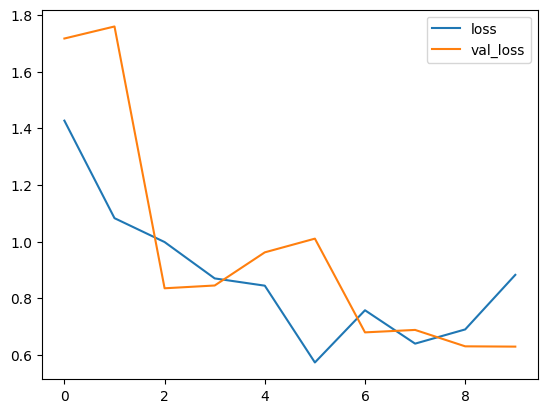

In [18]:
#plotando a loss por iteração

plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

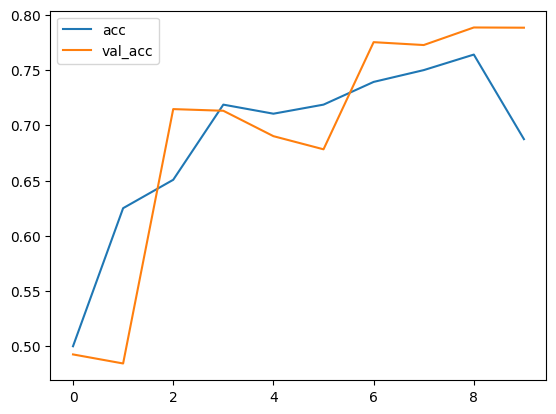

In [19]:
#plotando a acurácia por iteração

plt.plot(r.history['accuracy'], label='acc')
plt.plot(r.history['val_accuracy'], label='val_acc')
plt.legend()

In [20]:
#função para plotar a matriz de confusão com gráfico

from sklearn.metrics import confusion_matrix
import itertools

def plot_confusion_matrix(cm, classes, 
                          normalize=False, 
                          title='Confusion Matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion Matrix')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment='center',
                 color='white' if cm[i,j] > thresh else 'black')
        
    plt.tight_layout()
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Confusion Matrix
[[886  18  17  15   7   6   9   7  14  21]
 [ 11 929   2   3   2   3   5   4   5  36]
 [ 87   1 605  71  71  48  81  30   2   4]
 [ 29   2  25 644  59 116  78  34   8   5]
 [ 23   2  19  48 792  18  46  48   4   0]
 [  7   3  23 164  34 691  21  53   2   2]
 [  6   1  16  58  16  15 878   7   2   1]
 [ 15   2  16  37  33  23   8 862   1   3]
 [149  47   8  10   4   1   6   6 747  22]
 [ 36  65   1  19   3   4   6   8   8 850]]


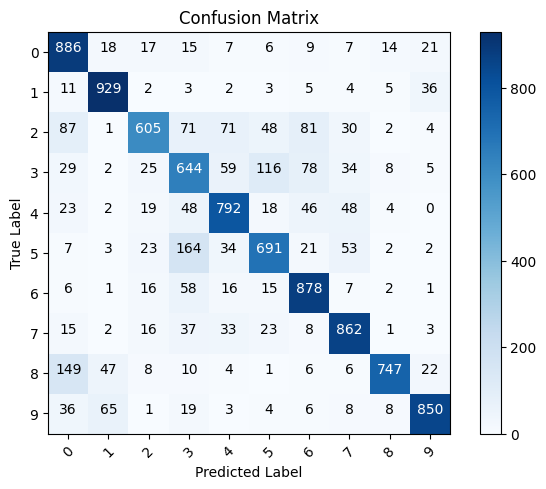

In [21]:
#plotando a matriz de confusão

p_teste = model.predict(X_teste).argmax(axis=1)
cm = confusion_matrix(y_teste, p_teste)
plot_confusion_matrix(cm, list(range(10)))